In [69]:
from brian2 import *
import time
import matplotlib.pyplot as plt

#Settings
start_scope()
DT = 0.01
defaultclock.dt = DT * ms
duration_in_min = 1/3
TotTime = int(duration_in_min*60000)
duration = TotTime * ms
N = 1000

print('Simulated minutes:', duration_in_min)
print('Simulated time steps(ms):', TotTime)
print('Neurons in the population:', N)

#Parameters
eta_bar= 0.
Delta=1.
E=0
J=0.05/N

Evar=np.append(np.zeros(int(N-N/4)),-80*np.ones(int(N/4)))

Kbath=15.5
z0=[-15.0, 0.45, -5, -16]

Vth= -50 # -60# buono -67.3# -19#
s=np.random.standard_cauchy(N)* Delta +eta_bar 
s=s[(s>-20+eta_bar)&(s<20+eta_bar)]
s=np.append(s,eta_bar*np.ones(N-len(s)))

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       ## Time costants
       'Cm': 1,
       'tau_n': 4,
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

eqs = '''
DNa_i = -DK_i : 1 (constant over dt)
DNa_o = -beta * DNa_i : 1 (constant over dt)
DK_o = -beta * DK_i : 1 (constant over dt)
K_i = K_i0 + DK_i : 1 (constant over dt)
Na_i = Na_i0 + DNa_i : 1 (constant over dt)
Na_o = Na_o0 + DNa_o : 1 (constant over dt)
K_o = K_o0 + DK_o + Kg : 1 (constant over dt)

n_inf= 1.0/(1.0+exp((Cnk-V)/DCnk)): 1
m_inf= 1.0/(1.0+exp((Cmna-V)/DCmna)): 1
h_n= 1.1 - 1.0 / (1.0 + exp(DChn * (n - Chn))): 1

I_K   = (g_Kl+g_K*n)*(V- 26.64*log(K_o/K_i)) : 1 
I_Na  = (g_Nal+g_Na*m_inf*h_n)*(V- 26.64*log(Na_o/Na_i)) : 1 
I_Cl  = g_Cl*(V+ 26.64*log(Cl_o0/Cl_i0)) : 1 
I_pump= rho*(1.0/(1.0+exp((Cnap - Na_i) / DCnap))*(1.0/(1.0+exp((Ckp - K_o)/DCkp)))) : 1 

dV/dt = (-1.0/Cm)*(I_Na+I_K+I_Cl+I_pump)+(eta)/tau_I: 1
dn/dt = (n_inf - n) / tau_n : 1
dDK_i/dt = -(gamma/w_i) * (I_K-2*I_pump): 1
dKg/dt = epsilon * (K_bath - K_o) : 1

Cnap : 1
DCnap : 1
Ckp : 1
DCkp : 1
Cmna : 1
DCmna : 1
Chn : 1
DChn : 1
Cnk : 1
DCnk : 1
Cm : second
tau_n : second
tau_I : second
g_Cl : 1
g_Na : 1
g_K : 1
g_Nal : 1
g_Kl : 1
w_i : 1
w_o : 1
rho : 1
beta : 1
epsilon : hertz
gamma : hertz
K_bath : 1
Na_i0 : 1
Na_o0 : 1
K_i0 : 1
K_o0 : 1
Cl_o0 : 1
Cl_i0 : 1
E : 1
J: 1
eta:1

'''

Population={}
G1 = NeuronGroup(N, eqs, threshold='V > Vth', refractory='V > Vth', method='heun') #rk4
G1.V = (z0[0]+1*randn(N)) * 1
G1.n = (z0[1]+0.05*randn(N)) * 1
G1.DK_i = z0[2]+0.3*randn(N) *1 #DK_i0 * 1
G1.Kg = z0[3]+0.3*randn(N) *1 #Kg0 * 1
G1.Cnap = Par['Cnap'] * 1  
G1.DCnap = Par['DCnap'] * 1 
G1.Ckp = Par['Ckp'] * 1  
G1.DCkp = Par['DCkp'] * 1  
G1.Cmna = Par['Cmna'] * 1  
G1.DCmna = Par['DCmna'] * 1  
G1.Chn = Par['Chn'] * 1  
G1.DChn = Par['DChn'] * 1 
G1.Cnk = Par['Cnk'] * 1  
G1.DCnk = Par['DCnk'] * 1  
G1.Cm = Par['Cm'] * ms  
G1.tau_n = Par['tau_n'] * ms   
G1.g_Cl = Par['g_Cl'] * 1  
G1.g_Na = Par['g_Na'] * 1  
G1.g_K = Par['g_K'] * 1  ,
G1.g_Nal = Par['g_Nal'] * 1  
G1.g_Kl = Par['g_Kl'] * 1 
G1.rho = Par['rho'] * 1  
G1.w_i = Par['w_i'] * 1
G1.w_o = Par['w_o'] * 1
G1.beta = Par['w_i'] / Par['w_o'] * 1 
G1.tau_I = Par['tau_I'] * ms  
G1.epsilon = Par['epsilon'] * (1 / ms)  
G1.gamma = Par['gamma'] * (1 / ms)  
G1.Na_i0 = Par['Na_i0'] * 1  
G1.Na_o0 = Par['Na_o0'] * 1  
G1.K_i0 = Par['K_i0'] * 1  
G1.K_o0 = Par['K_o0'] * 1  
G1.Cl_o0 = Par['Cl_o0'] * 1  
G1.Cl_i0 = Par['Cl_i0'] * 1  
G1.E = (E +Evar) * 1   
G1.J = J * 1  
G1.eta =s
G1.K_bath = Kbath * 1
print('K_bath=%.2f'%G1.K_bath[0])
print('J=%.6f'%G1.J[0])

MG1 = StateMonitor(G1, ('V', 'n', 'DK_i', 'Kg', 'K_o'), record=True, dt= 1*ms)
MG1_spike = SpikeMonitor(G1)
FRG1 = PopulationRateMonitor(G1)
S_G1G1 = Synapses(G1, G1, on_pre='V+=J*(E-V) ', method='heun')
S_G1G1.connect('i!=j')
net = Network(G1,MG1, MG1_spike, S_G1G1)

print('--##Start simulation##--')
tic = time.time()
run(duration, report='stdout', report_period=30*second)
tac = time.time()
print('--##End simulation##--')
print('Time : {}s'.format(tac - tic))

Population[Kbath]={}
Population[Kbath]['x']=np.var(MG1.V,axis=0)
Population[Kbath]['V']=np.mean(MG1.V,axis=0)
Population[Kbath]['n']=np.mean(MG1.n,axis=0)
Population[Kbath]['r']=FRG1.rate/Hz
Population[Kbath]['DK_i']=np.mean(MG1.DK_i,axis=0)
Population[Kbath]['Kg']=np.mean(MG1.Kg,axis=0)

Simulated minutes: 0.3333333333333333
Simulated time steps(ms): 20000
Neurons in the population: 1000
K_bath=15.50
J=0.000050
--##Start simulation##--


WARNING    "J" is an internal variable of group "synapses_1", but also exists in the run namespace with the value 5e-05. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. Abstract code: "V += J * (E - V) (in-place)"
 [brian2.codegen.generators.base]


Starting simulation at t=0. s for a duration of 20. s
0.99905 s (4%) simulated in 30s, estimated 9m 31s remaining.
2.09282 s (10%) simulated in 1m 0s, estimated 8m 33s remaining.
2.79571 s (13%) simulated in 1m 30s, estimated 9m 14s remaining.
2.99833 s (14%) simulated in 2m 0s, estimated 11m 20s remaining.
3.1522 s (15%) simulated in 2m 30s, estimated 13m 22s remaining.
3.28275 s (16%) simulated in 3m 0s, estimated 15m 17s remaining.
3.40939 s (17%) simulated in 3m 30s, estimated 17m 2s remaining.
3.53175 s (17%) simulated in 4m 0s, estimated 18m 39s remaining.
3.65573 s (18%) simulated in 4m 30s, estimated 20m 7s remaining.
3.77985 s (18%) simulated in 5m 0s, estimated 21m 27s remaining.
3.89505 s (19%) simulated in 5m 30s, estimated 22m 45s remaining.
4.02053 s (20%) simulated in 6m 0s, estimated 23m 51s remaining.
4.14899 s (20%) simulated in 6m 30s, estimated 24m 50s remaining.
4.28082 s (21%) simulated in 7m 0s, estimated 25m 42s remaining.
4.42318 s (22%) simulated in 7m 30s, es

KeyboardInterrupt: 

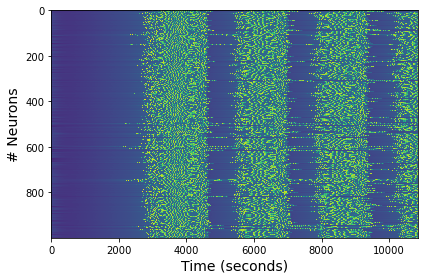

In [70]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.imshow(MG1.V,aspect='auto',interpolation='nearest',cmap='viridis')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

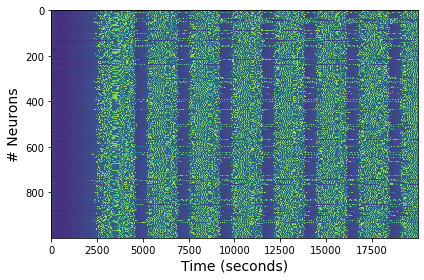

In [18]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.imshow(MG1.V,aspect='auto',interpolation='nearest',cmap='viridis')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

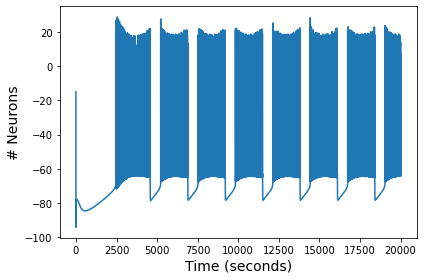

In [51]:
## plt.figure(figsize=(16,9))
#plt.title('Raster plot Mean Membrane potentials V_i')
plt.plot(MG1.V[352])
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
#plt.yticks([0,2900],[0,3000])
#plt.xticks(np.arange(3300)[::300],np.round(np.linspace(0,6,11),1))
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

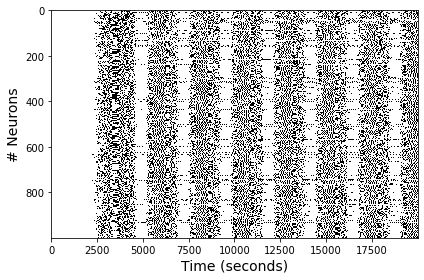

In [52]:
plt.figure(figsize=(6,4))
plt.imshow(np.where(MG1.V>-40,1,0)[:,:],aspect='auto',interpolation='none',cmap='gray_r')
plt.ylabel('# Neurons',fontsize='14')
plt.xlabel('Time (seconds)',fontsize='14')
plt.tight_layout()
#plt.savefig('Population_raster.pdf')
plt.show()

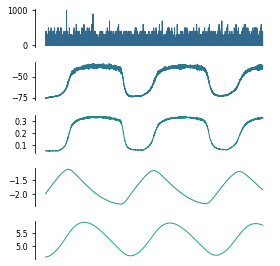

In [71]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

fig = plt.figure(figsize=(4,3.8))
ax1.set_title('Population')
ax1 = fig.add_subplot(511)
ax1.plot((FRG1.rate/hertz)[-6000:],c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(np.mean(MG1.V[:,-6000:],axis=0),c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(np.mean(MG1.n[:,-6000:],axis=0),c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(np.mean(MG1.DK_i[:,-6000:],axis=0),c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(np.mean(MG1.Kg[:,-6000:],axis=0),c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

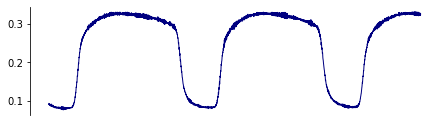

In [43]:
fig, ax = plt.subplots(figsize=(6.3,1.8))
ax.plot(np.mean(MG1.n[:,-6000:],axis=0),c='navy',linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=10)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

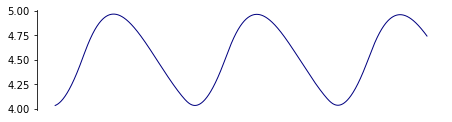

In [53]:
fig, ax = plt.subplots(figsize=(6.3,1.8))
ax.plot(np.mean(MG1.Kg[:,-6000:],axis=0),c='navy',linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=10)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

In [36]:
MG1.Kg.shape

(1000, 20000)

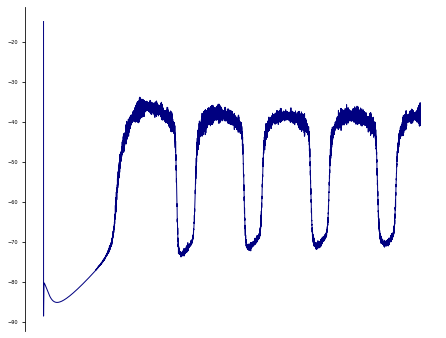

In [23]:
fig, ax = plt.subplots(figsize=(6.3,4.8))
ax.plot(np.mean(MG1.V[:,:13000],axis=0),c='navy',linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=5)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

In [59]:
viridis = cm.get_cmap('viridis', 16)
print(viridis)

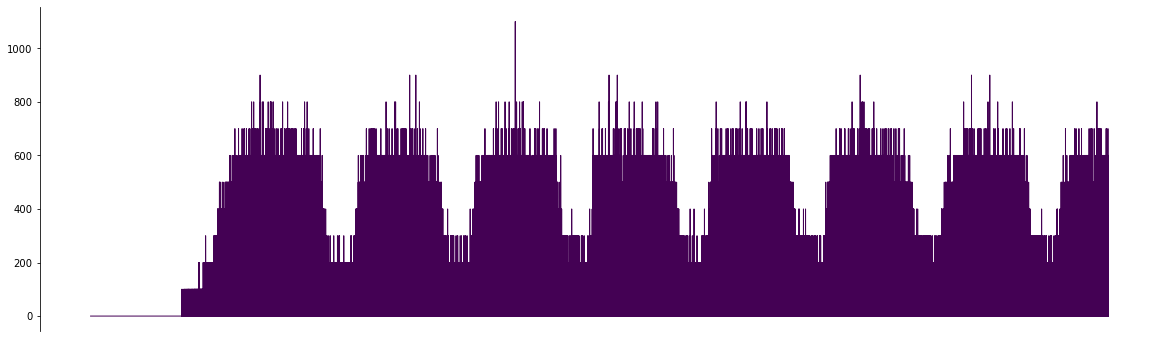

In [68]:
fig, ax = plt.subplots(figsize=(16.3,4.8))
ax.plot((FRG1.rate/hertz)[1000:],c=(0.267004, 0.004874, 0.329415, 1.0),linewidth=1)
#ax.hlines(0,0,105,color='k',linewidth=0.5)
#ax.set_ylim(2.998,3.002)
#ax.set_frame_on(0)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='both',labelsize=10)
#ax.set_yticks([])
plt.tight_layout()
#plt.savefig('K17.pdf')
plt.show()

In [27]:
FRG1.rate/hertz

array([100000.,      0.,      0., ...,    100.,    200.,    100.])

In [67]:
viridis(0)

(0.267004, 0.004874, 0.329415, 1.0)

In [276]:
from scipy import stats

In [ ]:
import pickle

def save_obj(obj, name ):
    with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

In [231]:
Pop={'V':MG1.V}

In [232]:
save_obj(Pop,'Fig4_Population_75')